# 12 — E8: Cross-Model Comparison

**Hypothesis H2:** Circuit structure is task-determined (language property), not training-determined.

Compares all E1–E7 outputs between Qwen and DeepSeek models.
Spearman rank correlations of concept-only fractions, meta-circuit sizes, flow type agreement.

In [1]:
# Cell 1 – Configuration
import subprocess, sys, os
for pkg in ["numpy", "pandas", "scipy", "matplotlib", "seaborn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

import ast as ast_mod
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

MODELS = ["QW", "DS"]
MODEL_CONFIGS = {
    "QW": {"id": "Qwen/Qwen2.5-Coder-7B",                "n_layers": 28, "mlp_dim": 3584},
    "DS": {"id": "deepseek-ai/deepseek-coder-6.7b-base",  "n_layers": 32, "mlp_dim": 4096},
}
LANGS = ["P", "R"]
EPSILON = "0.5"
CONSISTENCY = "0.8"
N_LAYERS = max(c["n_layers"] for c in MODEL_CONFIGS.values())

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import shutil
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)
    DATA_DIR = "/content/drive/MyDrive/DATA/New-Atlas"
else:
    DATA_DIR = "/Users/piotrwilam/Data/New-Atlas"



print(f"Models: {MODELS}, Langs: {LANGS}")
print(f"Settings: eps={EPSILON}, cons={CONSISTENCY}")

Models: ['QW', 'DS'], Langs: ['P', 'R']
Settings: eps=0.5, cons=0.8


In [2]:
# Cell 2 – Load neuron lists for all combos


def load_neuron_list(data_dir, prefix, eps, cons, obj_type="both"):
    """Load neuron list CSV, concatenating part1+part2 split files."""
    # Try split files first (new format)
    p1 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part1_{obj_type}.csv")
    p2 = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_layers_part2_{obj_type}.csv")
    if os.path.exists(p1) and os.path.exists(p2):
        return pd.concat([pd.read_csv(p1), pd.read_csv(p2)], ignore_index=True)
    # Fallback: try all_layers (old format)
    old = os.path.join(data_dir, f"{prefix}4_neuron_list_eps{eps}_cons{cons}_all_layers_{obj_type}.csv")
    if os.path.exists(old):
        return pd.read_csv(old)
    return None

data = {}  # (lang, model) -> DataFrame

neuron_data = {}  # (lang, model) -> DataFrame

for lang in LANGS:
    for model in MODELS:
        prefix = f"{lang}_{model}_"
        df = load_neuron_list(DATA_DIR if isinstance(DATA_DIR, str) else str(DATA_DIR), prefix, EPSILON, CONSISTENCY)
        if df is None:
            print(f"  Missing: {lang}_{model}")
            continue

        df["circuit_size"] = df["n_concept_only"] + df["n_both"]
        df["concept_fraction"] = df["n_concept_only"] / df["circuit_size"].replace(0, np.nan)
        neuron_data[(lang, model)] = df
        print(f"  {lang}_{model}: {len(df)} rows")

print(f"\nLoaded: {len(neuron_data)} datasets")

  P_QW: 1624 rows
  P_DS: 1856 rows
  R_QW: 1596 rows
  R_DS: 1824 rows

Loaded: 4 datasets


  P: rho=0.638, p=0.0000, n=58 objects


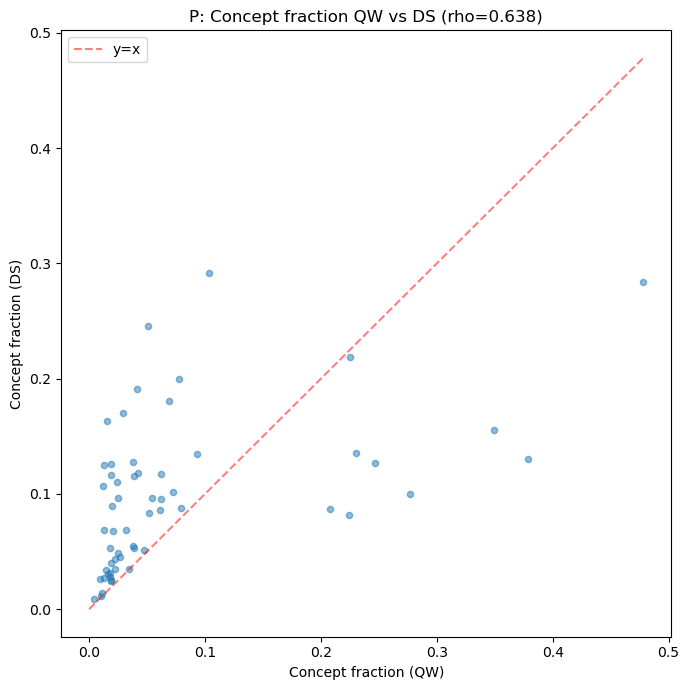

  R: rho=0.673, p=0.0000, n=57 objects


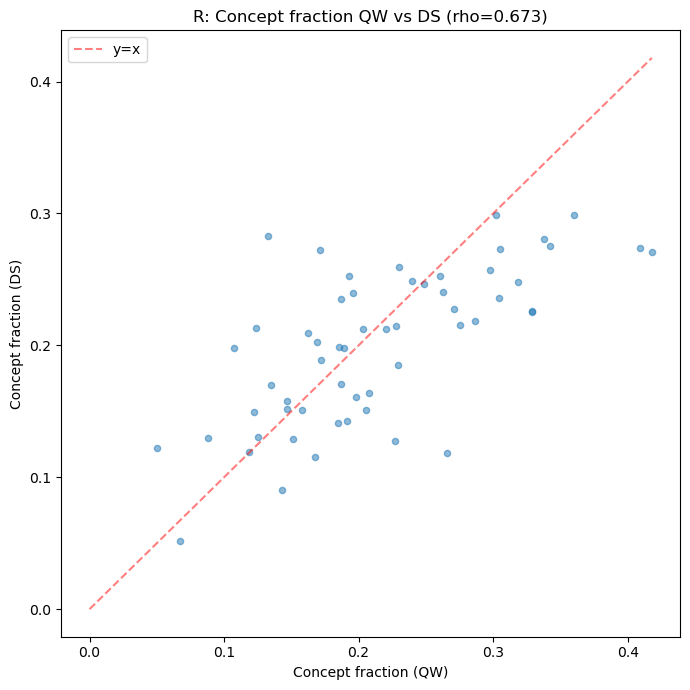

In [3]:
# Cell 3 – E2 comparison: concept-only fraction correlation across models

comparison_results = []

for lang in LANGS:
    dfs = {m: neuron_data.get((lang, m)) for m in MODELS}
    available = {m: df for m, df in dfs.items() if df is not None}

    if len(available) < 2:
        print(f"  {lang}: need both models for comparison")
        continue

    m1, m2 = MODELS[0], MODELS[1]
    df1, df2 = available[m1], available[m2]

    # Per-object mean concept fraction
    cf1 = df1.groupby("object")["concept_fraction"].mean().dropna()
    cf2 = df2.groupby("object")["concept_fraction"].mean().dropna()

    # Align on common objects
    common = sorted(set(cf1.index) & set(cf2.index))
    if len(common) < 3:
        print(f"  {lang}: only {len(common)} common objects — skipping")
        continue

    x = cf1[common].values
    y = cf2[common].values

    rho, p_val = stats.spearmanr(x, y)
    comparison_results.append({
        "lang": lang, "metric": "concept_fraction",
        "n_objects": len(common),
        "spearman_rho": rho, "p_value": p_val,
    })
    print(f"  {lang}: rho={rho:.3f}, p={p_val:.4f}, n={len(common)} objects")

    # Scatter plot
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x, y, alpha=0.5, s=20)
    ax.plot([0, max(x.max(), y.max())], [0, max(x.max(), y.max())],
            'r--', alpha=0.5, label="y=x")
    ax.set_xlabel(f"Concept fraction ({m1})")
    ax.set_ylabel(f"Concept fraction ({m2})")
    ax.set_title(f"{lang}: Concept fraction {m1} vs {m2} (rho={rho:.3f})")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, f"9_E8_cf_scatter_{lang}.png"), dpi=150)
    plt.show()

In [4]:
# Cell 4 – E1 comparison: circuit size correlation

for lang in LANGS:
    dfs = {m: neuron_data.get((lang, m)) for m in MODELS}
    available = {m: df for m, df in dfs.items() if df is not None}

    if len(available) < 2:
        continue

    m1, m2 = MODELS[0], MODELS[1]
    df1, df2 = available[m1], available[m2]

    cs1 = df1.groupby("object")["circuit_size"].mean()
    cs2 = df2.groupby("object")["circuit_size"].mean()
    common = sorted(set(cs1.index) & set(cs2.index))

    if len(common) >= 3:
        rho, p_val = stats.spearmanr(cs1[common].values, cs2[common].values)
        comparison_results.append({
            "lang": lang, "metric": "circuit_size",
            "n_objects": len(common),
            "spearman_rho": rho, "p_value": p_val,
        })
        print(f"  {lang} circuit size: rho={rho:.3f}, p={p_val:.4f}")

  P circuit size: rho=0.722, p=0.0000
  R circuit size: rho=0.790, p=0.0000


In [5]:
# Cell 5 – E6 comparison: flow type agreement (if available)

flow_type_path = os.path.join(DATA_DIR, "7_E6_flow_type_assignments.csv")
if os.path.exists(flow_type_path):
    df_ft = pd.read_csv(flow_type_path)

    for lang in LANGS:
        ft_models = {}
        for model in MODELS:
            sub = df_ft[(df_ft["lang"] == lang) & (df_ft["model"] == model)]
            if len(sub) > 0:
                ft_models[model] = sub.set_index("concept")["flow_type"]

        if len(ft_models) == 2:
            common = sorted(set(ft_models[MODELS[0]].index) & set(ft_models[MODELS[1]].index))
            if len(common) >= 3:
                matches = sum(ft_models[MODELS[0]][c] == ft_models[MODELS[1]][c] for c in common)
                agreement = matches / len(common)
                comparison_results.append({
                    "lang": lang, "metric": "flow_type_agreement",
                    "n_objects": len(common),
                    "spearman_rho": agreement,  # reusing column for agreement rate
                    "p_value": np.nan,
                })
                print(f"  {lang} flow type agreement: {agreement:.0%} ({matches}/{len(common)})")
else:
    print("  Flow type data not available — run notebook 10 first.")

  P flow type agreement: 88% (93/106)
  R flow type agreement: 84% (63/75)


In [6]:
# Cell 6 – Summary table

df_comparison = pd.DataFrame(comparison_results)
if len(df_comparison) > 0:
    print("CROSS-MODEL COMPARISON SUMMARY")
    print("=" * 60)
    display(df_comparison)

    # H2 headline: is rho > 0.7?
    cf_rows = df_comparison[df_comparison["metric"] == "concept_fraction"]
    if len(cf_rows) > 0:
        mean_rho = cf_rows["spearman_rho"].mean()
        print(f"\nH2 headline: mean Spearman rho of concept fractions = {mean_rho:.3f}")
        print(f"  {'SUPPORTED' if mean_rho > 0.7 else 'NOT SUPPORTED'} (threshold: 0.7)")
else:
    print("No comparison results — need both QW and DS data.")

CROSS-MODEL COMPARISON SUMMARY


,lang,metric,n_objects,spearman_rho,p_value
0,P,concept_fraction,58,0.638377,7.003078e-08
1,R,concept_fraction,57,0.672997,9.756220e-09
2,P,circuit_size,58,0.721554,1.657732e-10
3,R,circuit_size,57,0.789875,2.808580e-13
4,P,flow_type_agreement,106,0.877358,NaN
5,R,flow_type_agreement,75,0.840000,NaN



H2 headline: mean Spearman rho of concept fractions = 0.656
  NOT SUPPORTED (threshold: 0.7)


In [7]:
# Cell 7 – Save

if len(df_comparison) > 0:
    out_path = os.path.join(DATA_DIR, "9_E8_cross_model_results.csv")
    df_comparison.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

print("\n12 complete.")

Saved: /Users/piotrwilam/Data/New-Atlas/9_E8_cross_model_results.csv

12 complete.
